# Mexico Real Estate Price Analysis
## Part 3: Correlation and Variable Relationships

> **How do you go from "it looks like a positive relationship" to a rigorous,
> reproducible statement?**

## 1. Setup and Data Loading

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_path = "../data/mexico-real-estate-combined-analysis-clean.csv"

# Load the data
data = pd.read_csv(data_path)

# Verify the load
print(f"Dimensions: {data.shape[0]} rows and {data.shape[1]} columns.")
data.head()

Dimensions: 1365 rows and 6 columns.


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


## 2. The Pearson Correlation Coefficient

### 2.1 Calculating the National Area-Price Correlation

In [32]:
# Calculate correlation between 'area_m2' and 'price_usd'
corr_price_area = (
    data["area_m2"]
    .corr(data["price_usd"])
)

print(f"The correlation between Area and Price is: {corr_price_area:.4f}")

The correlation between Area and Price is: 0.4612


**What it means precisely:**

The Pearson r of approximately 0.46 between `area_m2` and `price_usd` tells us
that roughly **21% of the variance in price can be "explained" by area** (because
r² = 0.46² ≈ 0.21). In plain language: if you know nothing about a property except
its size, knowing the area reduces your uncertainty about the price by about 21%.
The remaining 79% of price variation is explained by other factors — location,
property type, condition, amenities, and factors we have not measured.

## 3. The Correlation Matrix and Heatmaps

Often, we want to check the relationships between *all* numerical variables at
once — not just area vs price. 

### 3.1 Computing the Matrix


In [33]:
# Select only numerical columns
# Compute the correlation matrix
corr_matrix = (
    data
    .select_dtypes("number") # to select the numeric data only
    .corr()
)

corr_matrix

,lat,lon,area_m2,price_usd
lat,1.000000,-0.468427,0.111037,-0.110904
lon,-0.468427,1.000000,0.147243,0.091938
area_m2,0.111037,0.147243,1.000000,0.461186
price_usd,-0.110904,0.091938,0.461186,1.000000


### 3.2 Visualizing with a Heatmap

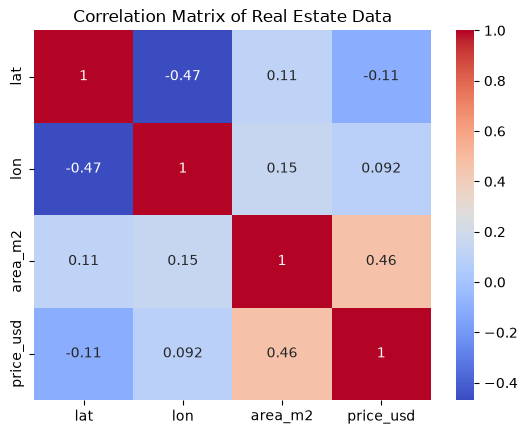

In [34]:
# Create a figure
fig, ax = plt.subplots()

# Create the heatmap using Seaborn
# annot=True adds the numbers to the boxes
# cmap="coolwarm" creates a nice Red (hot/positive) to Blue (cold/negative) spectrum
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", ax=ax)

ax.set_title("Correlation Matrix of Real Estate Data")
plt.show()

## 4. Segmented Correlations: Why Averages Lie

The national r = 0.46 is our starting point — not our conclusion. The next
question is: **is this relationship consistent across all states, or does it
vary dramatically?**

In [36]:
# Calculate correlation by state
state_counts = data.groupby("state").size()

correlations_by_state = (
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()                          # Build correlation matrix per state
    .iloc[:, 1]                      # Keep only the price_usd column
    .xs("area_m2", level=1)          # Extract one correlation value per state
    .sort_values(ascending=False)    # Rank strongest to weakest
)

state_corr = (
    pd.DataFrame({
        "corr": correlations_by_state,
        "n": state_counts
    })
    .sort_values("corr", ascending=False)
)


print(correlations_by_state.head(5))
print("\n... and the bottom 5 ...\n")
print(correlations_by_state.tail(5))

print("\nStates with less than 30 listings:")
print(state_corr.query("n < 30").sort_values("corr", ascending=False))

state
Zacatecas              1.000000
Colima                 0.932415
Tlaxcala               0.929545
Baja California Sur    0.914063
Querétaro              0.833773
Name: price_usd, dtype: float64

... and the bottom 5 ...

state
Tabasco             0.384510
Quintana Roo        0.382091
Distrito Federal    0.312744
Nuevo León          0.235177
Oaxaca             -1.000000
Name: price_usd, dtype: float64

States with less than 30 listings:
                         corr   n
state                            
Zacatecas            1.000000   2
Colima               0.932415   4
Tlaxcala             0.929545   5
Baja California Sur  0.914063  12
Campeche             0.824161   3
Sonora               0.813470   7
Durango              0.780264   5
Nayarit              0.774295   9
Hidalgo              0.708272  15
Guanajuato           0.703606  10
Chihuahua            0.697244  16
Baja California      0.601036  23
Sinaloa              0.422235  23
Aguascalientes       0.414952   6
Tabasco     

Some states have very few listings. Correlations based on very small samples can be extreme and unreliable. Therefore, we should interpret state-level correlations cautiously, especially for states with fewer than 30 listings.

> **The broader lesson — Simpson's Paradox:**
>
> The national r = 0.46 is a weighted average of state-level correlations ranging
> from near-zero to 0.9+. This average does not describe any state accurately.
>
> This is an instance of **Simpson's Paradox**: a trend that appears in aggregate
> data can reverse or disappear when you examine subgroups separately.
> 
### 4.2 Correlation by Property Type

Do houses and apartments follow the same pricing logic?


In [37]:
# Calculate correlation by property_type
correlations_by_prop = (
    data
    .groupby("property_type")   # groupby `"property_type"`
    [["area_m2", "price_usd"]]    # we select by the `"area_m2"` and `"price_usd"` columns
    .corr()
    .iloc[:, 1]
    .xs("area_m2", level=1) # extracts the `"area_m2"` correlation value from the inner index level.
)

print(correlations_by_prop)

property_type
apartment    0.407360
house        0.619962
Name: price_usd, dtype: float64


> 📊 **Reading the property-type correlations**
>
> You see two numbers:
> - **Houses:** r ≈ 0.62 — strong positive. Size is a reliable predictor of
>   house prices.
> - **Apartments:** r ≈ 0.40 — moderate positive. Size matters, but less reliably.

## 5. Feature Engineering: Price per Square Meter

We have been analyzing `price_usd` (total price) as the outcome. But total price
is *confounded* by size: a large property almost always costs more in total,
even if it is cheaper per square meter.
To isolate the **value of location and quality** from the **effect of size**, we
create a new column: **price per square meter**.

### 5.1 Creating the Feature


In [38]:
# Create new column
data = (
    data
    .assign(price_per_m2 = lambda x: x["price_usd"] / x["area_m2"])
)

data.head()

,property_type,state,lat,lon,area_m2,price_usd,price_per_m2
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56,453.103733
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78,339.912796
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37,1028.028902
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80,628.725333
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37,513.128634


### 5.2 Visualizing the Law of Diminishing Returns

> **Does an extra square meter add the same value to a 30 m² studio as to
> a 300 m² villa?**

In economics, the **law of diminishing returns** states that adding more of one
input (size) produces progressively smaller gains in the output (price per m²).
The first square meter of a tiny studio is extremely valuable — you need some
minimum space to live. But the 300th square meter of a large villa adds
proportionally less value: the owners are already wealthy and the space is already
comfortable.

**How to see this in the data:** If we plot `area_m2` on the x-axis and
`price_per_m2` on the y-axis, we should see a *decreasing* curve — not a straight
line going down (which would imply linear diminishing returns), but a curve that
drops steeply for small areas and then flattens as area grows.

This is important because Pearson r measures *linear* relationships. If the true
relationship between area and `price_per_m2` is curved (hyperbolic), Pearson r
will understate the relationship. This is why feature engineering matters: the
curved relationship between area and `price_per_m2` may actually be *stronger*
than the linear r suggests.

**Scatterplot of `area_m2` vs `price_per_m2`:**

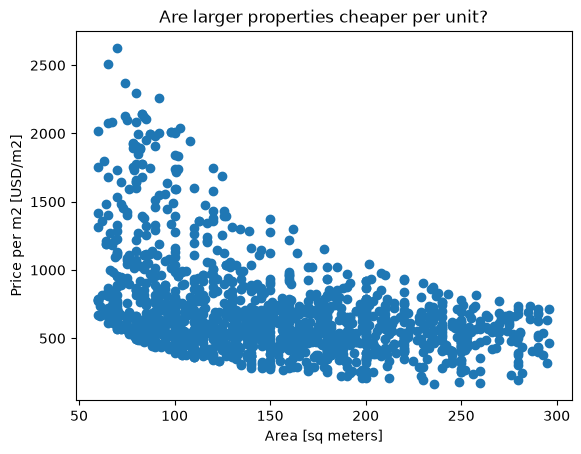

In [30]:
fig, ax = plt.subplots()

# Scatter plot
ax.scatter(x=data["area_m2"], y=data["price_per_m2"],)

ax.set_title("Are larger properties cheaper per unit?")
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price per m2 [USD/m2]")

plt.show()